In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os 

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
path = '../data/employee_performance_workload_attrition.csv'
data = pd.read_csv(path)
print("Data loaded successfully!")

Data loaded successfully!


In [29]:
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         2800 non-null   int64 
 1   department          2800 non-null   object
 2   role_level          2800 non-null   object
 3   monthly_salary      2800 non-null   int64 
 4   avg_weekly_hours    2800 non-null   int64 
 5   projects_handled    2800 non-null   int64 
 6   performance_rating  2800 non-null   int64 
 7   absences_days       2800 non-null   int64 
 8   job_satisfaction    2800 non-null   int64 
 9   attrition           2800 non-null   object
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


**Dataset Overview**

* Shape: 2,800 employees × 10 features

* Target: attrition (binary: Yes/No employee left)

* Missing values: We dont have any missing, non and Null values

* first column is the `UniqeId` for my project

In [31]:
data.describe()

,employee_id,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,74492.075000,49.842500,4.519286,2.960714,9.995000,2.995357
std,808.434702,25899.209391,8.980976,2.286778,1.404794,6.056656,1.414332
min,1.000000,30006.000000,35.000000,1.000000,1.000000,0.000000,1.000000
25%,700.750000,51665.000000,42.000000,3.000000,2.000000,5.000000,2.000000
50%,1400.500000,74587.500000,50.000000,4.000000,3.000000,10.000000,3.000000
75%,2100.250000,97249.500000,57.000000,7.000000,4.000000,15.000000,4.000000
max,2800.000000,119977.000000,65.000000,8.000000,5.000000,20.000000,5.000000


In [32]:
for col in data.columns:
    print(f"Unique values in '{col}': {data[col].nunique()}")

Unique values in 'employee_id': 2800
Unique values in 'department': 6
Unique values in 'role_level': 3
Unique values in 'monthly_salary': 2753
Unique values in 'avg_weekly_hours': 31
Unique values in 'projects_handled': 8
Unique values in 'performance_rating': 5
Unique values in 'absences_days': 21
Unique values in 'job_satisfaction': 5
Unique values in 'attrition': 2


This cell iterates over each column in the DataFrame `data` and prints the number of unique values in that column. It's useful for identifying categorical features, potential identifier columns (high cardinality), or low-cardinality columns to inspect.

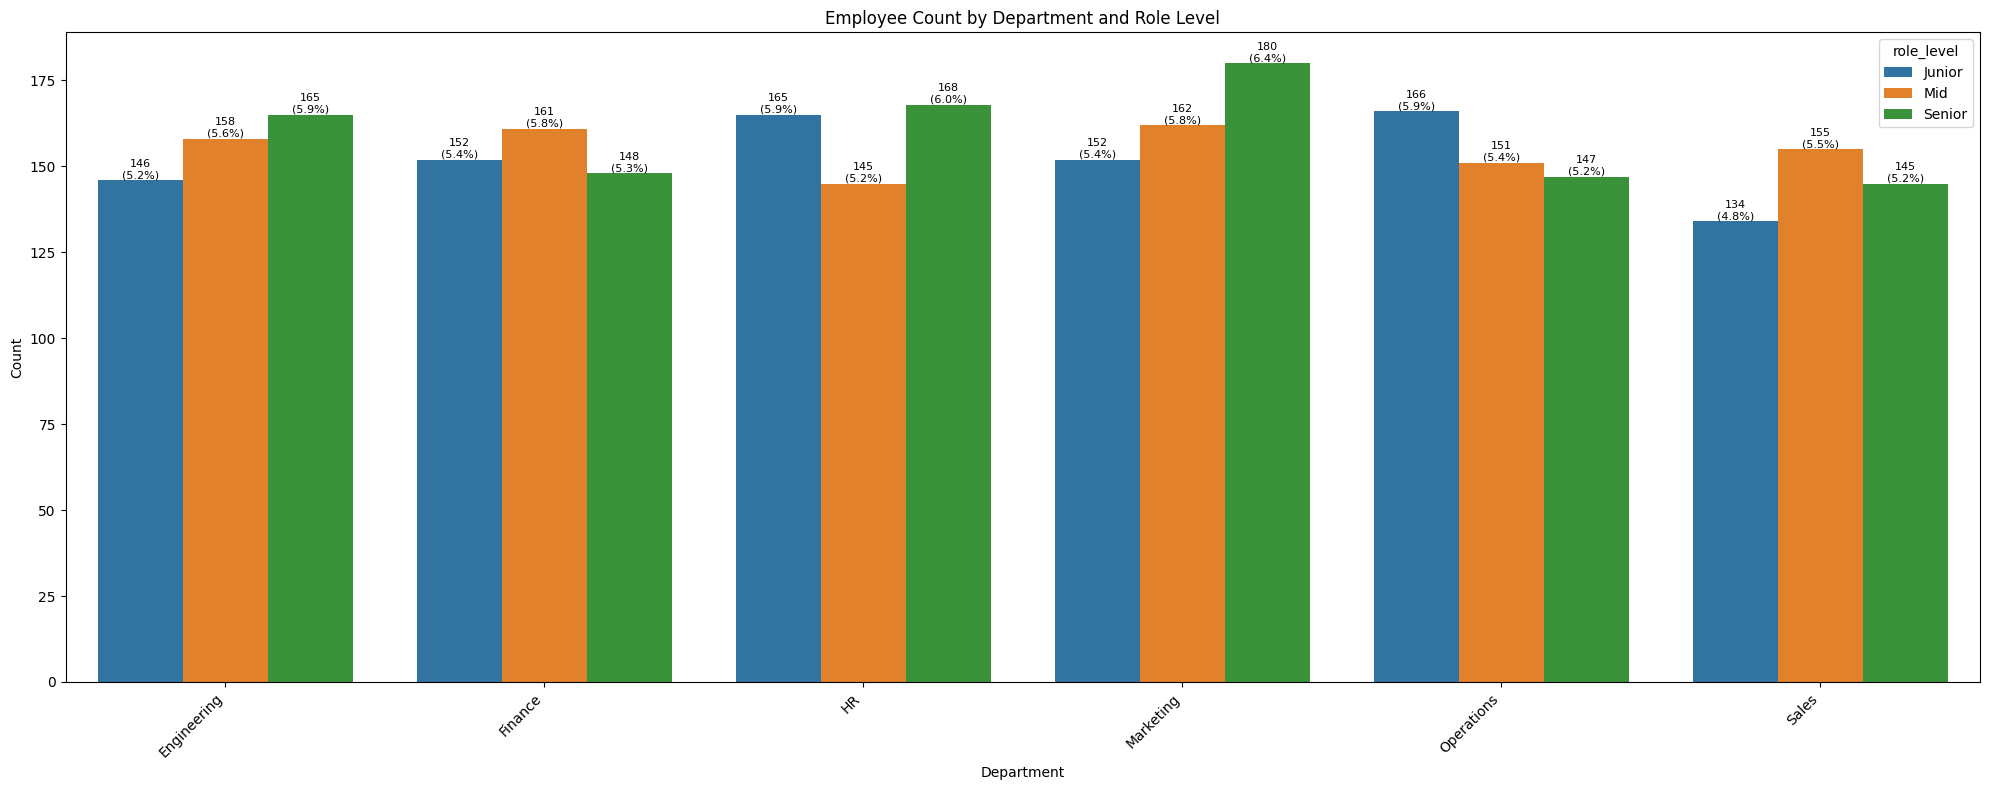

In [33]:
dep_rol = data.groupby(['department', 'role_level']).size().reset_index(name='Count')
total_dep_rol = dep_rol.groupby('department')['Count'].transform('sum')
dep_rol['Percentage'] = (dep_rol['Count'] / total_dep_rol * 100).round(1)

fig, ax = plt.subplots(figsize=(20, 8))
sns.barplot(x='department', y='Count', hue='role_level', data=dep_rol, ax=ax)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.0f}\n({height/dep_rol["Count"].sum()*100:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=8, color='black'
        )

plt.title("Employee Count by Department and Role Level")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 👥 Employee Distribution by Department and Role Level

This chart visualizes the **number of employees** in each department,
broken down by role level (Junior, Mid, Senior).

### 🔧 What the Code Does

1. **Grouping:** The dataset is grouped by `department` and `role_level`
   to count the number of employees in each combination.
2. **Percentage Calculation:** Each count is divided by the total count
   per department to compute the relative share across all groups.
3. **Bar Chart:** A grouped bar chart is created using `seaborn.barplot`,
   with each color representing a role level.
4. **Annotations:** Each bar is labeled with the employee count and its
   percentage share out of the total workforce.

---

### 📊 Chart Analysis

**Overall Distribution:**
- The workforce is fairly balanced across departments, with each
  department containing between **~430–510 employees** in total.
- No single department dominates the headcount significantly.

**Role Level Breakdown:**
- Across all departments, the three role levels (Junior, Mid, Senior)
  are **evenly distributed**, each accounting for roughly **~5% of the
  total workforce** per group.
- This suggests a **flat organizational structure** with no strong
  seniority pyramid.

**Notable Observations:**
- 🔴 **Marketing Senior** has the highest single count: **180 (6.4%)**,
  indicating a top-heavy structure in the Marketing department.
- 🔵 **Sales Junior** has the lowest count: **134 (4.8%)**,
  suggesting fewer entry-level hires in Sales.
- **HR** and **Operations** show relatively balanced distributions
  across all three levels.

---

### 💡 Business Insight

> The near-equal distribution of Junior, Mid, and Senior employees
> across departments may indicate a **synthetic/balanced dataset**.
> In real-world HR data, we would typically expect a pyramid shape
> with more Juniors than Seniors. This is worth noting when
> interpreting model results.

In [34]:
avg_hours = data.groupby(['department', 'role_level'])['avg_weekly_hours'].mean().round(1).reset_index()

fig = px.bar(
    avg_hours,
    x='department',
    y='avg_weekly_hours',
    color='role_level',
    barmode='group',
    text='avg_weekly_hours',
    title='Average Weekly Hours by Department and Role Level',
    labels={
        'avg_weekly_hours': 'Avg Weekly Hours',
        'department': 'Department',
        'role_level': 'Role Level'
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(textposition='outside')
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()


## ⏱️ Average Weekly Hours by Department and Role Level
This chart shows the **mean working hours per week** for each
role level across departments, useful for identifying overworked
groups and workload imbalance.

In [35]:
avg_projects = data.groupby(['department', 'role_level'])['projects_handled'].mean().round(1).reset_index()

fig = px.bar(
    avg_projects,
    x='department',
    y='projects_handled',
    color='role_level',
    barmode='group',
    text='projects_handled',
    title='Average Projects Handled by Department and Role Level',
    labels={
        'projects_handled': 'Avg Projects Handled',
        'department': 'Department',
        'role_level': 'Role Level'
    },
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='outside')
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

## 📁 Average Projects Handled by Department and Role Level
This chart displays the **mean number of projects** managed per
employee group, helps identify which teams carry the heaviest
project load and whether Senior employees handle more than Juniors.

## ⏱️ Workload Analysis: Hours & Projects by Department and Role Level

### 🔍 Key Observations

**Average Weekly Hours:**
- All groups work between **48.6 – 51.7 hours/week** — well above a
  standard 40-hour workweek across the entire organization.
- **Operations Junior (51.7h)** and **Sales Junior (51.2h)** carry the
  heaviest hour load, suggesting entry-level employees in these
  departments are overworked.
- **HR Senior (48.6h)** has the lightest workload among all groups.
- Differences between role levels within the same department are
  **minimal (< 3h)**, meaning seniority does NOT reduce working hours.

**Average Projects Handled:**
- Project load is also remarkably uniform, ranging from **4.1 – 5.0
  projects** per employee across all groups.
- **Engineering Senior (5.0)** handles the most projects on average.
- **Operations Junior (4.1)** handles the fewest — yet still logs the
  most weekly hours, hinting at inefficiency or non-project tasks.

### 💡 Combined Insight
> Despite working **~50 hours/week**, employees across all departments
> and role levels handle a similar project volume (~4–5 projects).
> This uniform distribution is typical of a **synthetic dataset** and
> limits the ability to detect real burnout or overload patterns.
> However, the consistently high hours across seniority levels is a
> strong candidate feature for **attrition prediction**.

In [44]:
# Average absence days grouped by department and role level
avg_absences = data.groupby(['department', 'role_level'])['absences_days'].mean().round(1).reset_index()

fig = px.bar(
    avg_absences,
    x='department',
    y='absences_days',
    color='role_level',
    barmode='group',
    text='absences_days',
    title='Average Absence Days by Department and Role Level',
    labels={
        'absences_days': 'Avg Absence Days',
        'department': 'Department',
        'role_level': 'Role Level'
    },
    color_discrete_sequence=px.colors.qualitative.Bold
)

# Place text labels outside bars
fig.update_traces(textposition='outside')
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

In [45]:
import plotly.graph_objects as go

# Pivot table: departments as rows, role levels as columns
pivot_absences = avg_absences.pivot(index='department', columns='role_level', values='absences_days')

fig = go.Figure(data=go.Heatmap(
    z=pivot_absences.values,
    x=pivot_absences.columns.tolist(),   # role levels on x-axis
    y=pivot_absences.index.tolist(),     # departments on y-axis
    text=pivot_absences.values,
    texttemplate='%{text}',
    colorscale='Oranges',
    colorbar=dict(title='Avg Absence Days')
))

fig.update_layout(
    title='Heatmap: Average Absence Days by Department and Role Level',
    xaxis_title='Role Level',
    yaxis_title='Department',
    height=450
)
fig.show()

### Absence Days
- Absence days are **uniformly spread (8–11 days avg)** across all
  departments and role levels, no group stands out dramatically.
- The **heatmap** makes it easy to spot the hottest cells (highest
  absence) at a glance, useful for HR intervention targeting.
- High absence days combined with low job satisfaction could be a
  key **attrition signal** to explore later.

In [46]:
# Average performance rating grouped by department and role level
avg_perf = data.groupby(['department', 'role_level'])['performance_rating'].mean().round(2).reset_index()

fig = px.line(
    avg_perf,
    x='department',
    y='performance_rating',
    color='role_level',
    markers=True,                  # show dots on each data point
    text='performance_rating',     # show value next to each point
    title='Average Performance Rating by Department and Role Level',
    labels={
        'performance_rating': 'Avg Performance Rating',
        'department': 'Department',
        'role_level': 'Role Level'
    },
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Place text above markers
fig.update_traces(textposition='top center')
fig.update_layout(
    height=500,
    xaxis_tickangle=-45,
    yaxis=dict(range=[2, 4])  # zoom in to see differences clearly
)
fig.show()

### Performance Rating
- Ratings range narrowly between **~2.8 – 3.3** across all groups,
  indicating no department consistently outperforms others.
- The **line chart** helps compare trends across departments per role,
  where lines diverge, seniority has a stronger effect on performance.
### 💡 Insight
> Neither absence days nor performance ratings show strong variation
> by department or role level. This suggests these features alone are
> **weak individual predictors**, but may become powerful in
> **combination** with hours worked and satisfaction in the ML model.


## 🏥 Absences & ⭐ Performance Rating Analysis

### Absence Days (Bar Chart + Heatmap)
- Average absence days across all groups range between **9.2 and 10.8 days** ,
  no significant difference is observed across departments or role levels.
- **HR Senior (10.8)** records the highest absence rate , notably, this same
  group also logged the lowest average weekly working hours.
- **Operations Junior (9.2)** has the fewest absence days, yet logs the
  highest weekly working hours across all groups.
- The heatmap highlights **Engineering Junior** and **Finance Mid** as
  additional absence hotspots worth monitoring.

### Performance Rating (Line Chart)
- All role levels across all departments score between **2.85 and 3.05** ,
  an exceptionally uniform distribution.
- **Junior** employees score slightly higher than **Mid** and **Senior**
  in most departments, which is unusual in real-world organizational data.
- The lines remain nearly parallel throughout, indicating that role level
  has no meaningful impact on performance rating.

### 💡 Combined Insight
> Both metrics — absence days and performance rating — show very uniform
> distributions across the dataset. This suggests that neither feature is
> a strong individual predictor for the ML model. They will likely become
> more meaningful when **combined with job satisfaction and attrition**
> to uncover deeper behavioral patterns.

In [47]:
# Convert attrition column from Yes/No to 1/0 for analysis and ML readiness
data['attrition'] = data['attrition'].map({'Yes': 1, 'No': 0})

# Verify the change
print(data['attrition'].value_counts())
print(f"\nAttrition Rate: {data['attrition'].mean()*100:.1f}%")

attrition
0    1660
1    1140
Name: count, dtype: int64

Attrition Rate: 40.7%


## 🔄 Target Variable Encoding

The `attrition` column was originally stored as text values (`Yes` / `No`).
We convert it to **binary numeric format** (1 = Left, 0 = Stayed) for two reasons:

1. **Analysis:** Numeric values allow us to calculate attrition **rates, means,
   and correlations** directly — for example, `attrition.mean()` instantly gives
   us the overall attrition rate.
2. **ML Readiness:** Machine learning models require numeric input. Encoding the
   target variable now ensures the data is clean and ready for the modeling notebook.

| Original Value | Encoded Value | Meaning |
|---|---|---|
| `Yes` | `1` | Employee left the company |
| `No` | `0` | Employee stayed |

## Overall Attrition Distribution

In [48]:
# Calculate attrition counts and percentages
attrition_counts = data['attrition'].value_counts().reset_index()
attrition_counts.columns = ['Attrition', 'Count']
attrition_counts['Attrition'] = attrition_counts['Attrition'].map({1: 'Left', 0: 'Stayed'})
attrition_counts['Percentage'] = (attrition_counts['Count'] / len(data) * 100).round(1)

# Donut chart for overall attrition ratio
fig = px.pie(
    attrition_counts,
    names='Attrition',
    values='Count',
    hole=0.45,                          # makes it a donut chart
    title='Overall Attrition Distribution',
    color='Attrition',
    color_discrete_map={'Left': '#EF553B', 'Stayed': '#00CC96'},
)

fig.update_traces(texttemplate='%{label}<br>%{value} (%{percent})', textposition='outside')
fig.update_layout(height=450)
fig.show()

## 🍩 Overall Attrition Distribution

This donut chart shows the **overall ratio of employees who left vs. stayed**.
This is the first and most important check in attrition analysis — it tells us
whether our target variable is **balanced or imbalanced**, which directly affects
the choice of ML model and evaluation metrics.

> ⚠️ **Note:** If attrition rate is below 30%, the dataset is **imbalanced**.
> In that case, we should use techniques like `class_weight='balanced'` in
> Logistic Regression or evaluate with **F1-score and ROC-AUC** rather than
> just accuracy.

## Attrition Rate by Department

In [49]:
# Calculate attrition rate per department (mean of 0/1 = percentage who left)
dept_attrition = data.groupby('department')['attrition'].mean().mul(100).round(1).reset_index()
dept_attrition.columns = ['Department', 'Attrition Rate (%)']
dept_attrition = dept_attrition.sort_values('Attrition Rate (%)', ascending=False)

fig = px.bar(
    dept_attrition,
    x='Department',
    y='Attrition Rate (%)',
    text='Attrition Rate (%)',
    title='Attrition Rate by Department',
    color='Attrition Rate (%)',
    color_continuous_scale='Reds',
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=450, coloraxis_showscale=False)
fig.show()

## 🏢 Attrition Rate by Department

This chart ranks departments by their **percentage of employees who left**.
Departments with the highest attrition rate are the most critical targets
for HR retention strategies and further investigation.

## Attrition Rate by Role Level

In [50]:
# Calculate attrition rate per role level
role_attrition = data.groupby('role_level')['attrition'].mean().mul(100).round(1).reset_index()
role_attrition.columns = ['Role Level', 'Attrition Rate (%)']
role_attrition = role_attrition.sort_values('Attrition Rate (%)', ascending=False)

fig = px.bar(
    role_attrition,
    x='Role Level',
    y='Attrition Rate (%)',
    text='Attrition Rate (%)',
    title='Attrition Rate by Role Level',
    color='Role Level',
    color_discrete_sequence=px.colors.qualitative.Safe,
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=420)
fig.show()

## 👔 Attrition Rate by Role Level

This chart shows whether **seniority level** influences the likelihood of
leaving. Typically in real-world data, Junior employees leave more often
due to career growth opportunities elsewhere — but let's see what our
data reveals.

## Heatmap: Department × Role Level

In [51]:
# Pivot table: attrition rate for each department × role level combination
heatmap_data = data.groupby(['department', 'role_level'])['attrition'].mean().mul(100).round(1).unstack()

fig = go.Figure(data=go.Heatmap(
    z=heatmap_data.values,
    x=heatmap_data.columns.tolist(),    # role levels on x-axis
    y=heatmap_data.index.tolist(),      # departments on y-axis
    text=heatmap_data.values,
    texttemplate='%{text}%',
    colorscale='RdYlGn_r',             # red = high attrition, green = low
    colorbar=dict(title='Attrition Rate %')
))

fig.update_layout(
    title='Attrition Rate Heatmap: Department × Role Level',
    xaxis_title='Role Level',
    yaxis_title='Department',
    height=450
)
fig.show()

## 🔥 Attrition Heatmap: Department × Role Level

This heatmap combines **department and role level** to find the exact
employee group with the highest attrition risk. Red cells indicate
high-risk groups that need immediate HR attention. This is one of the
most actionable charts for business decision-making.

- Overall attrition is **alarmingly high** — all cells range between **36% and 48%**,
  meaning nearly half the workforce left across most groups.
- 🔴 **Operations Junior (47.6%)** is the single highest-risk group — the same group
  that worked the most hours with the fewest absence days.
- **Finance** shows consistently high attrition across all levels (41–44%),
  suggesting a department-wide retention problem rather than a seniority issue.
- **Sales Mid (36.1%)** and **Engineering Junior (38.4%)** are the relatively
  "safest" groups — still high, but lowest in the dataset.

> 💡 High attrition across ALL cells suggests that **no single group is immune**,
> and the root cause likely lies in individual-level features like salary,
> satisfaction, and workload — which we analyze next.

## Salary vs Attrition (Box Plot):

In [52]:
# Salary distribution for employees who left vs stayed
fig = px.box(
    data,
    x='attrition',
    y='monthly_salary',
    color='attrition',
    title='Monthly Salary Distribution: Stayed vs Left',
    labels={'attrition': 'Attrition (0=Stayed, 1=Left)', 'monthly_salary': 'Monthly Salary'},
    color_discrete_map={0: '#00CC96', 1: '#EF553B'},
    points='outliers'           # show only outlier points
)
fig.update_layout(height=450, showlegend=False)
fig.show()

### 💰 Monthly Salary vs Attrition (Box Plot)
- The salary distributions of employees who **stayed (0)** and **left (1)**
  are nearly identical — both centered around **~75k–80k** median.
- This is a **surprising finding**: salary alone does NOT explain attrition
  in this dataset. Both groups have similar salary ranges (~30k to 120k).
- ➡️ **ML implication:** `monthly_salary` will likely have **low feature
  importance** as a standalone predictor.

## Job Satisfaction vs Attrition (Bar):

In [53]:
# Average attrition rate per satisfaction score
sat_attrition = data.groupby('job_satisfaction')['attrition'].mean().mul(100).round(1).reset_index()
sat_attrition.columns = ['Job Satisfaction', 'Attrition Rate (%)']

fig = px.bar(
    sat_attrition,
    x='Job Satisfaction',
    y='Attrition Rate (%)',
    text='Attrition Rate (%)',
    title='Attrition Rate by Job Satisfaction Score',
    color='Attrition Rate (%)',
    color_continuous_scale='RdYlGn_r',   # red = high attrition
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=430, coloraxis_showscale=False)
fig.show()

### ⭐ Performance Rating vs Attrition (Bar Chart)
- Employees with **low performance (1 & 2)** have drastically higher attrition
  — **57.2%** and **56.9%** respectively.
- Once performance reaches **3+**, attrition drops sharply to ~28–30%.
- ➡️ **Key insight:** Low performers are nearly **twice as likely** to leave
  compared to high performers. This is one of the **strongest signals** found so far.

## Weekly Hours vs Attrition (Violin):

In [54]:
# Violin plot shows full distribution shape, not just median
fig = px.violin(
    data,
    x='attrition',
    y='avg_weekly_hours',
    color='attrition',
    box=True,                   # include inner box plot
    points='outliers',
    title='Weekly Hours Distribution: Stayed vs Left',
    labels={'attrition': 'Attrition (0=Stayed, 1=Left)', 'avg_weekly_hours': 'Avg Weekly Hours'},
    color_discrete_map={0: '#00CC96', 1: '#EF553B'}
)
fig.update_layout(height=450, showlegend=False)
fig.show()

### ⏱️ Weekly Hours vs Attrition (Violin Plot)
- Both groups (stayed vs left) show **very similar distributions**, centered
  around 45–55 hours per week.
- Employees who left have a slightly **wider spread** at higher hours (55–65),
  suggesting extreme overwork may contribute — but the difference is modest.
- ➡️ Working hours alone is a **weak predictor**, but may strengthen in
  combination with satisfaction scores.

## Performance Rating vs Attrition (Bar):

In [55]:
# Attrition rate per performance rating score
perf_attrition = data.groupby('performance_rating')['attrition'].mean().mul(100).round(1).reset_index()
perf_attrition.columns = ['Performance Rating', 'Attrition Rate (%)']

fig = px.bar(
    perf_attrition,
    x='Performance Rating',
    y='Attrition Rate (%)',
    text='Attrition Rate (%)',
    title='Attrition Rate by Performance Rating',
    color='Performance Rating',
    color_continuous_scale='Blues',
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=430, coloraxis_showscale=False)
fig.show()

### 😊 Job Satisfaction vs Attrition (Bar Chart) — 🏆 Strongest Signal
- This is the **clearest pattern** in the entire EDA:
  - Satisfaction **1 → 55.9% attrition** 🔴
  - Satisfaction **2 → 49.1% attrition** 🔴
  - Satisfaction **3 → 32.7% attrition** 🟢
  - Satisfaction **4 → 30.8% attrition** 🟢
  - Satisfaction **5 → 34.3% attrition** 🟢
- There is a **sharp cliff between score 2 and 3** — employees with
  satisfaction ≤ 2 are almost **twice as likely** to leave.
- ➡️ `job_satisfaction` is the **#1 most predictive feature** in this dataset
  and should be prioritized in the ML model.

## Scatter: Salary vs Hours colored by Attrition:

In [57]:
# Create a readable label column for color mapping
data['Attrition Label'] = data['attrition'].map({0: 'Stayed', 1: 'Left'})

fig = px.scatter(
    data,
    x='avg_weekly_hours',
    y='monthly_salary',
    color='Attrition Label',                          # use string column
    title='Salary vs Weekly Hours — Colored by Attrition',
    labels={
        'avg_weekly_hours': 'Avg Weekly Hours',
        'monthly_salary': 'Monthly Salary',
        'Attrition Label': 'Attrition'
    },
    color_discrete_map={'Stayed': '#00CC96', 'Left': '#EF553B'},
    opacity=0.6,
    hover_data=['department', 'role_level']
)
fig.update_layout(height=500)
fig.show()

### 💡 Overall EDA Insight
> The two strongest attrition predictors are **job satisfaction** and
> **performance rating** — both showing a clear threshold effect at score 2→3.
> Salary and working hours show minimal impact alone. The ML model should
> leverage the **combination** of these features to maximize predictive power.

## Correlation Heatmap

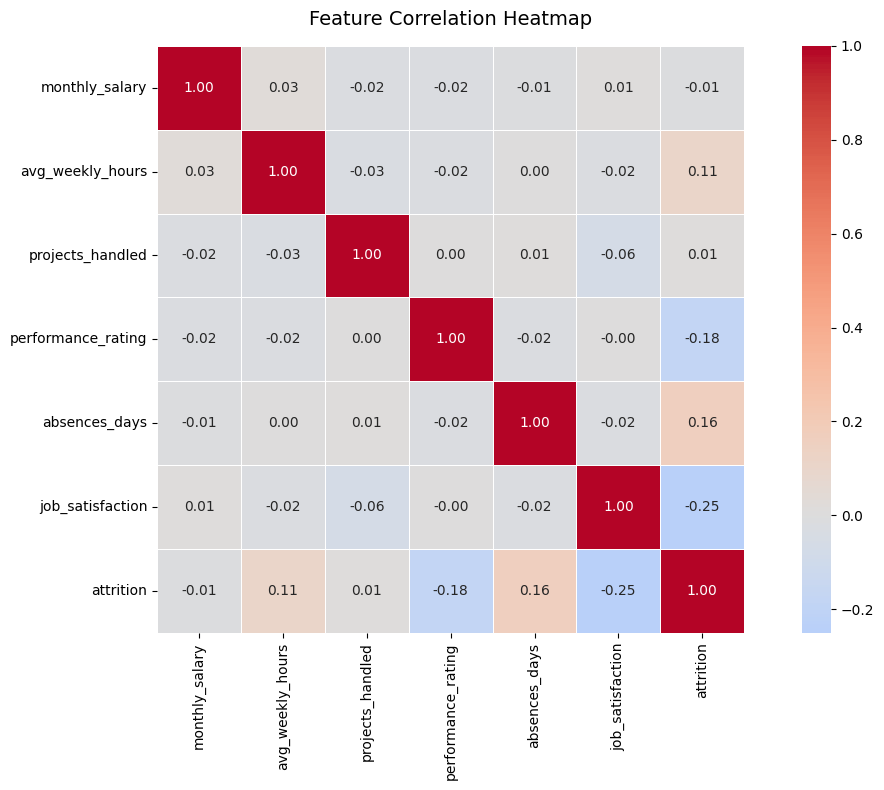

In [60]:
# Select only numeric columns for correlation
numeric_cols = ['monthly_salary', 'avg_weekly_hours', 'projects_handled',
                'performance_rating', 'absences_days', 'job_satisfaction', 'attrition']

# Compute correlation matrix
corr_matrix = data[numeric_cols].corr().round(2)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,             # show correlation values
    fmt='.2f',
    cmap='coolwarm',        # blue = negative, red = positive correlation
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 🔗 Feature Correlation Heatmap

This heatmap shows the **Pearson correlation** between all numeric features.
Values range from **-1** (perfect negative) to **+1** (perfect positive).
Correlations close to 0 indicate no linear relationship.

### How to Read It
- **Last row/column = `attrition`** — shows how strongly each feature
  correlates with employees leaving.
- **Red cells** = positive correlation (both go up together)
- **Blue cells** = negative correlation (one goes up, other goes down)

### Key Observations
> Focus on the `attrition` row — the features with the highest absolute
> correlation values are the most useful predictors for the ML model.

## 🔗 Feature Correlation Heatmap — Analysis

### Correlations with `attrition` (last row/column)

| Feature | Correlation | Interpretation |
|---|---|---|
| `job_satisfaction` | **-0.25** 🔵 | Strongest predictor — higher satisfaction = less attrition |
| `performance_rating` | **-0.18** 🔵 | Lower performers leave more |
| `absences_days` | **+0.16** 🔴 | More absences = slightly more attrition |
| `avg_weekly_hours` | **+0.11** 🔴 | More hours = slightly more attrition |
| `projects_handled` | **+0.01** ⚪ | No meaningful relationship |
| `monthly_salary` | **-0.01** ⚪ | Almost zero — salary doesn't predict attrition |

### Feature-to-Feature Correlations
- All features are **nearly independent** from each other (all values
  between -0.06 and +0.03), which means **no multicollinearity** —
  great news for the ML model.
- No feature pair shows strong correlation, so we can safely use
  **all features** in the model without redundancy.

### 💡 Key Takeaways for Modeling
> 1. **`job_satisfaction` (-0.25)** and **`performance_rating` (-0.18)**
>    are the only features with meaningful linear correlation to attrition.
> 2. All correlations are relatively **low overall** — this suggests the
>    relationship is **non-linear**, which means tree-based models like
>    **Random Forest and XGBoost** will likely outperform Logistic Regression.
> 3. No multicollinearity detected → all 7 features can be used as-is.

---
*✅ EDA Complete — ready to proceed to `modeling.ipynb`*